In [ ]:
# --- 1. Install Dependencies ---
!pip install -q transformers diffusers accelerate xformers

import os
import glob
import torch
import shutil
import random
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler
from transformers import pipeline
import warnings

warnings.filterwarnings("ignore")

DATA_DIR = "/content/data/monodepth_kaggle2026/train/"
OUTPUT_DIR = "/content/data/monodepth_kaggle2026/train_overgrown/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

KAGGLE_TOKEN = ''
if not os.path.exists(DATA_DIR):
    os.environ['KAGGLE_API_TOKEN'] = KAGGLE_TOKEN
    !kaggle competitions download -c ethz-cil-monocular-depth-estimation-2026 -p /content/
    !unzip -q /content/ethz-cil-monocular-depth-estimation-2026.zip -d /content/data/
    !rm /content/ethz-cil-monocular-depth-estimation-2026.zip


controlnet = ControlNetModel.from_pretrained("lllyasviel/control_v11f1p_sd15_depth", torch_dtype=torch.float16)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", controlnet=controlnet, torch_dtype=torch.float16, safety_checker=None
).to("cuda")
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

try:
    pipe.enable_xformers_memory_efficient_attention()
    print("xFormers memory efficient attention enabled.")
except Exception:
    pass

depth_estimator = pipeline("depth-estimation", model="depth-anything/Depth-Anything-V2-Large-hf", device=0)

def round_to_multiple(x, multiple=8):
    return int(round(x / multiple) * multiple)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 92.6 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


100% 20.6G/20.6G [19:20<00:00, 19.1MB/s]

Loading Models into GPU (This takes about a minute, but only runs once)...


config.json:   0%|          | 0.00/945 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/503 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Models loaded and ready!


Testing Prompt:
'A modern building completely overgrown with dense green ivy, surrounded by lush trees and thick vegetation, hyperrealistic, highly detailed'
Generating 3 samples...


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

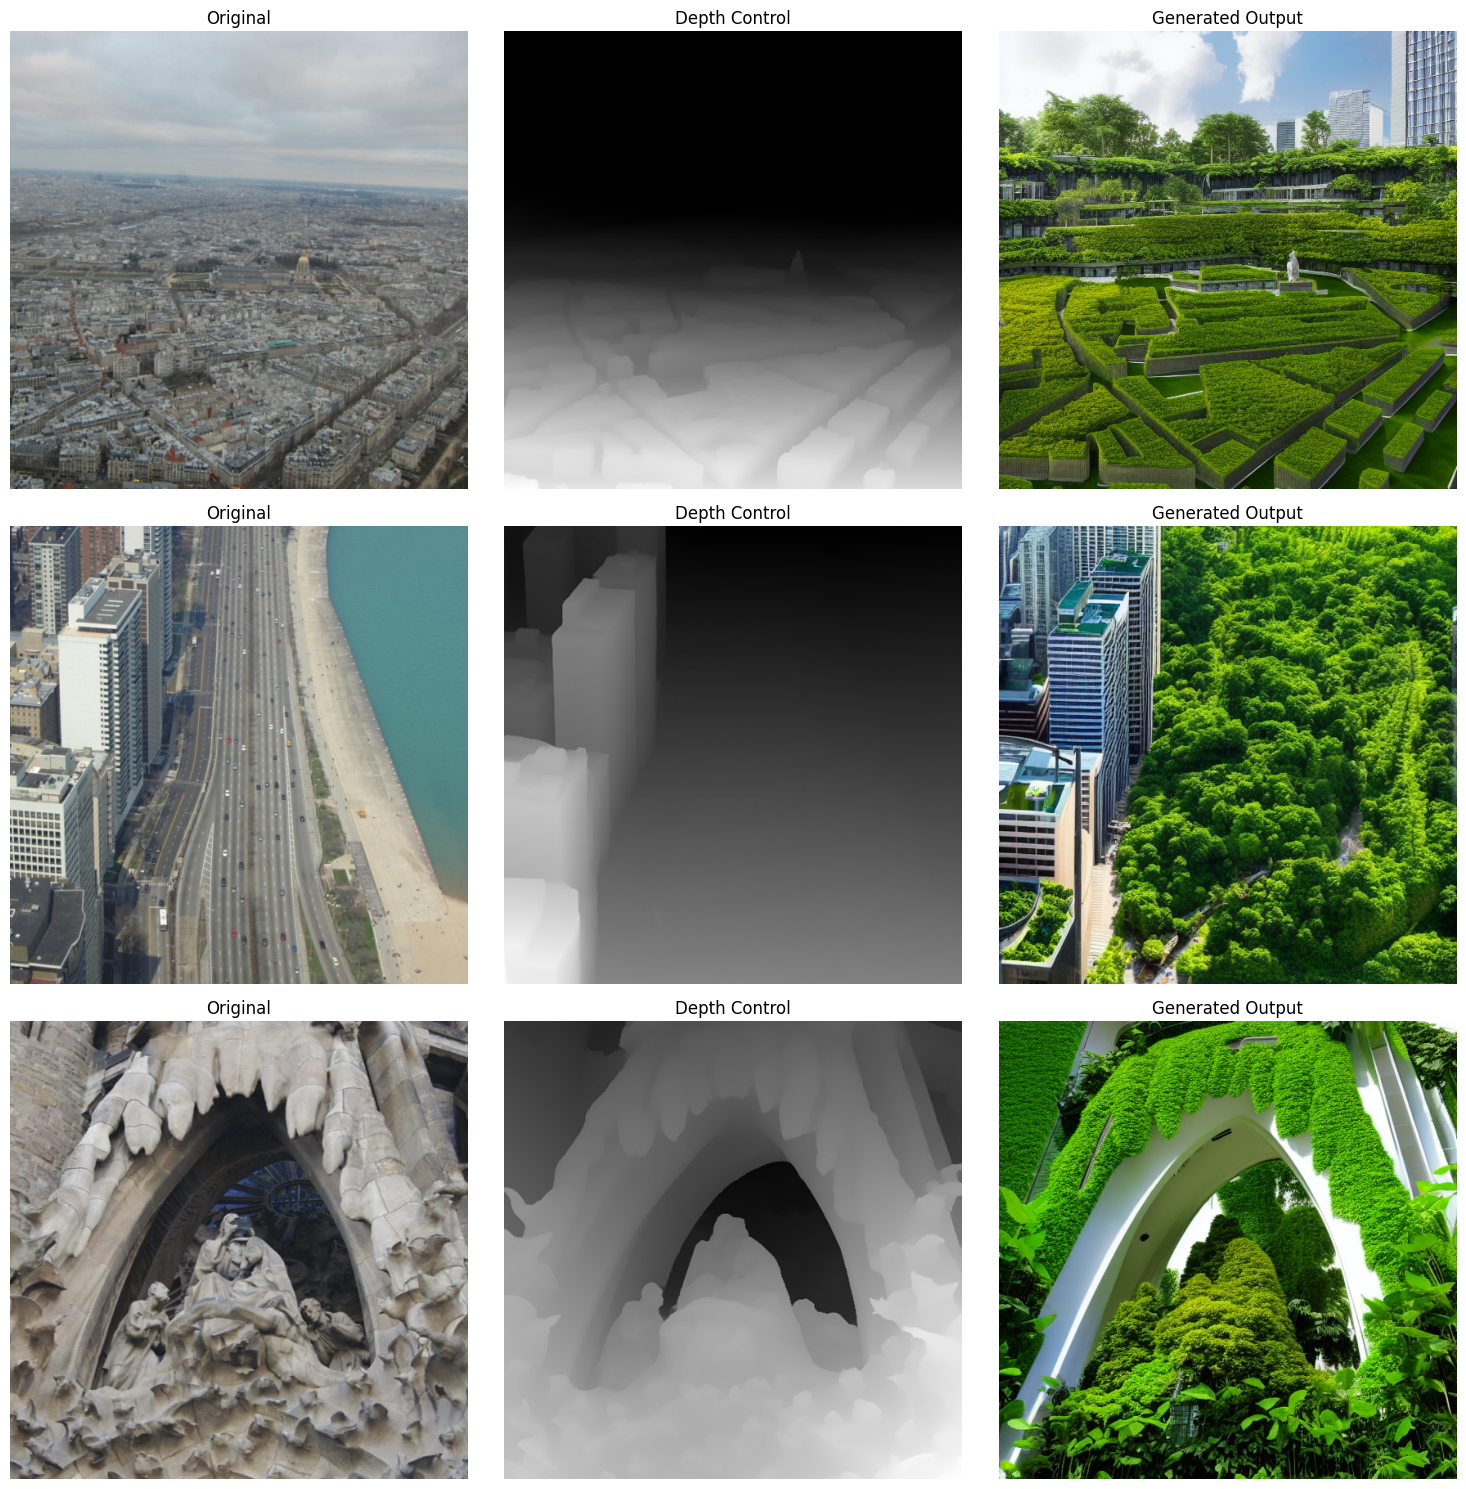

In [ ]:
TEST_PROMPT = "A modern building completely overgrown with dense green ivy, surrounded by lush trees and thick vegetation, hyperrealistic, highly detailed"
NEGATIVE_PROMPT = "low quality, blurry, deformed, smooth concrete, plain, indoors, out of frame, cartoon, illustration"

NUM_IMAGES_TO_TEST = 3

def experiment_with_prompt(prompt, negative_prompt, num_samples):
    rgb_files = sorted(glob.glob(os.path.join(DATA_DIR, "*_rgb.png")))
    sample_files = random.sample(rgb_files, min(num_samples, len(rgb_files)))

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1: axes = [axes]

    print(f"Testing Prompt:\n'{prompt}'\nGenerating {num_samples} samples...")

    for i, rgb_path in enumerate(sample_files):
        orig_img = Image.open(rgb_path).convert("RGB")
        gen_w, gen_h = round_to_multiple(orig_img.width), round_to_multiple(orig_img.height)
        orig_img_resized = orig_img.resize((gen_w, gen_h))

        cond_image = depth_estimator(orig_img_resized)['depth']

        with torch.autocast("cuda"):
            output_image = pipe(
                prompt=prompt,
                negative_prompt=negative_prompt,
                image=cond_image,
                height=gen_h,
                width=gen_w,
                num_inference_steps=20,
                controlnet_conditioning_scale=1.0,
                guidance_scale=7.5,
            ).images[0]

        axes[i][0].imshow(orig_img_resized)
        axes[i][0].set_title("Original", fontsize=12)
        axes[i][0].axis('off')

        axes[i][1].imshow(cond_image, cmap='gray')
        axes[i][1].set_title("Depth Control", fontsize=12)
        axes[i][1].axis('off')

        axes[i][2].imshow(output_image)
        axes[i][2].set_title("Generated Output", fontsize=12)
        axes[i][2].axis('off')

    plt.tight_layout()
    plt.show()

experiment_with_prompt(TEST_PROMPT, NEGATIVE_PROMPT, NUM_IMAGES_TO_TEST)

In [ ]:
from google.colab import files
from tqdm import tqdm


FINAL_PROMPT = "A modern building completely overgrown with dense green ivy, surrounded by lush trees and thick vegetation, hyperrealistic, highly detailed"
FINAL_NEGATIVE_PROMPT = "low quality, blurry, deformed, smooth concrete, plain, indoors, out of frame, cartoon, illustration"

NUM_SAMPLES_TO_GENERATE = 4000

def generate_production_dataset(num_samples, prompt, negative_prompt):
    rgb_files = sorted(glob.glob(os.path.join(DATA_DIR, "*_rgb.png")))
    random.seed(42)
    random.shuffle(rgb_files)
    rgb_files = rgb_files[:num_samples]

    print(f"Starting production run for {len(rgb_files)} images...")

    for rgb_path in tqdm(rgb_files):
        base_name = os.path.basename(rgb_path).replace("_rgb.png", "")
        orig_npy_path = os.path.join(DATA_DIR, f"{base_name}_depth.npy")
        out_rgb_path = os.path.join(OUTPUT_DIR, f"{base_name}_overgrown_rgb.png")
        out_npy_path = os.path.join(OUTPUT_DIR, f"{base_name}_overgrown_depth.npy")

        if os.path.exists(out_rgb_path) and os.path.exists(out_npy_path):
            continue

        orig_img = Image.open(rgb_path).convert("RGB")
        orig_w, orig_h = orig_img.size

        gen_w, gen_h = round_to_multiple(orig_w), round_to_multiple(orig_h)
        orig_img_resized = orig_img.resize((gen_w, gen_h))

        cond_image_resized = depth_estimator(orig_img_resized)['depth']

        with torch.autocast("cuda"):
            output_image = pipe(
                prompt=prompt,
                negative_prompt=negative_prompt,
                image=cond_image_resized,
                height=gen_h,
                width=gen_w,
                num_inference_steps=20,
                controlnet_conditioning_scale=1.0,
                guidance_scale=7.5,
            ).images[0]

        final_image = output_image.resize((orig_w, orig_h))
        final_image.save(out_rgb_path)

        if os.path.exists(orig_npy_path):
            shutil.copy2(orig_npy_path, out_npy_path)

generate_production_dataset(NUM_SAMPLES_TO_GENERATE, FINAL_PROMPT, FINAL_NEGATIVE_PROMPT)

shutil.make_archive(
    base_name='/content/train_overgrown_dataset',
    format='zip',
    root_dir=OUTPUT_DIR
)
files.download('/content/train_overgrown_dataset.zip')